# OSS Maintenance Model Training

This notebook is the primary, thesis-visible workflow for the fixed Logistic Regression and XGBoost artifact bundle used by OSS Risk Radar. Python package modules own the implementation; this notebook exposes the data, features, split, evaluation, and artifact export path end to end. The main research framing is early warning before inactivity or archival, so archived repositories may enter the sampling frame while already-archived observation rows are excluded from model fitting.

## Python Module Map

The notebook is intentionally small because the reusable Python package owns the implementation. These are the main scripts/modules behind each visible step.

| Notebook step | Python module | What it owns |
| --- | --- | --- |
| 1. Problem and label definition | `app.training.maintenance_dataset.labels` | Converts historical activity windows into the `label_inactive_12m` target. |
| 2. GHArchive and data preparation | `app.training.maintenance_dataset.pipeline` | Builds training snapshots from seed repositories, GHArchive event windows, repository metadata, and scorecard data. |
| 2. GHArchive and data preparation | `app.training.maintenance_dataset.events` | Parses GHArchive event JSON into normalized repository activity events. |
| 2. GHArchive and data preparation | `app.training.maintenance_dataset.storage` | Reads local hourly GHArchive files and feeds the dataset builder. |
| 3. Feature engineering | `app.training.maintenance_dataset.features` | Aggregates historical event windows into repository-level training signals. |
| 3. Feature engineering | `app.modeling.features` | Converts dependency/repository snapshots into the stable model feature vector used by training and runtime scoring. |
| 4. Time-aware split | `app.training.datasets` | Loads snapshots, filters labeled rows, and creates chronological train/validation/test splits. |
| 5. Logistic Regression training | `app.modeling.baseline` | Trains and serializes the Logistic Regression baseline. |
| 5. XGBoost training | `app.modeling.xgboost_model` | Trains and serializes the XGBoost model. |
| 5. Evaluation | `app.training.evaluation` | Computes model metrics and model quality summaries. |
| 5. Calibration | `app.training.calibration` | Builds calibration bins for artifact metadata and dashboard plots. |
| 6. Artifact export | `app.training.artifact_export` | Computes the Go-compatible dataset hash, trains full-history and cold-start Logistic Regression/XGBoost artifacts, writes run JSON files, and updates `latest-run.json`. |
| Runtime scoring | `app.scoring.model` | Loads staged artifacts and scores submitted GitHub repositories/dependencies with the trained models. |
| Internal API bridge | `app.api.routes` | Exposes internal model scoring and feature extraction endpoints to the Go API. |

## 1. Problem And Label Definition

The target is `label_inactive_12m`: whether a repository becomes inactive or archived during the 12 months after an observation date. Labels come from historical GHArchive coverage, not from user-submitted GitHub URLs. Seed buckets such as active, dormant, or archived are sampling provenance only. Runtime analysis scores submitted repositories with the staged artifacts exported at the end of this notebook.

In [1]:
from __future__ import annotations

# Parameters. Papermill overrides this cell during headless training runs.
dataset_mode = "processed"  # processed | rebuild | smoke
dataset_path = "tmp/training/snapshots.json"
feature_cache_path = "tmp/training/repository-feature-cache.json"
intermediate_dir = "tmp/training/oss-maintenance"
seed_file = "tmp/training/foundation-seed.csv"
gharchive_sources = []  # Repeatable local files/directories; never downloaded here.
runs_dir = "tmp/training/runs"
latest_run_path = "tmp/training/latest-run.json"
model_names = ["logistic-regression-full-history", "xgboost-full-history", "logistic-regression-cold-start", "xgboost-cold-start"]
train_ratio = 0.75
validation_ratio = 0.15
calibration_bins = 10
label_horizon_months = 12
observation_start = "2023-01-01"
observation_end = "2024-01-01"
observation_interval_months = 3
sample_limit_per_ecosystem = 5000
sample_seed = 42
minimum_repositories = 0
minimum_snapshots = 3
require_complete_coverage = True
replace_training_output = True
force = False
export_artifacts = True
execution_timeout_seconds = 900  # Runner-level Papermill limit, recorded for reproducibility.


In [2]:
import json
import csv
import sys
from datetime import UTC, date, datetime, timedelta
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "mltraining" / "scoring" / "app").exists():
            return candidate
    raise RuntimeError("could not locate repository root from notebook working directory")


def resolve_repo_path(value: str | Path) -> Path:
    candidate = Path(value)
    return candidate if candidate.is_absolute() else REPO_ROOT / candidate


def add_months(value: date, months: int) -> date:
    month_index = value.month - 1 + months
    year = value.year + month_index // 12
    month = month_index % 12 + 1
    day = min(value.day, 28)
    return date(year, month, day)


def infer_latest_complete_gharchive_date(source_dir: Path | None = None) -> date | None:
    if source_dir is None:
        return None
    if not source_dir.exists() or not source_dir.is_dir():
        return None
    hours_by_date: dict[str, set[int]] = {}
    for item in source_dir.iterdir():
        if not item.is_file() or item.suffix != ".gz":
            continue
        stem = item.name.removesuffix(".json.gz")
        date_part, _, hour_part = stem.rpartition("-")
        if not date_part or not hour_part.isdigit():
            continue
        hours_by_date.setdefault(date_part, set()).add(int(hour_part))
    complete_dates = sorted(day for day, hours in hours_by_date.items() if len(hours) == 24)
    return date.fromisoformat(complete_dates[-1]) if complete_dates else None


REPO_ROOT = find_repo_root(Path.cwd())
SCORING_ROOT = REPO_ROOT / "mltraining" / "scoring"
if str(SCORING_ROOT) not in sys.path:
    sys.path.insert(0, str(SCORING_ROOT))
importlib.invalidate_caches()

import app.modeling.features as modeling_features_module
import app.training.datasets as datasets_module
import app.training.pipeline as pipeline_module
import app.training.maintenance_dataset.pipeline as maintenance_dataset_pipeline_module
import app.training.artifact_export as artifact_export_module

# Interactive notebook kernels cache imports across edits. Reload local modules so the notebook
# always uses the workspace implementation, not a stale import from an earlier cell run.
modeling_features_module = importlib.reload(modeling_features_module)
datasets_module = importlib.reload(datasets_module)
pipeline_module = importlib.reload(pipeline_module)
maintenance_dataset_pipeline_module = importlib.reload(maintenance_dataset_pipeline_module)
artifact_export_module = importlib.reload(artifact_export_module)

DatasetBuildConfig = maintenance_dataset_pipeline_module.DatasetBuildConfig
DatasetBuilder = maintenance_dataset_pipeline_module.DatasetBuilder
PipelineAdapters = maintenance_dataset_pipeline_module.PipelineAdapters

ArtifactExportConfig = artifact_export_module.ArtifactExportConfig
best_run = artifact_export_module.best_run
build_artifact_runs = artifact_export_module.build_artifact_runs
compute_go_dataset_hash = artifact_export_module.compute_go_dataset_hash
load_raw_snapshot_items = artifact_export_module.load_raw_snapshot_items
prepare_artifact_export = artifact_export_module.prepare_artifact_export
write_artifact_bundle = artifact_export_module.write_artifact_bundle

build_dataset = datasets_module.build_dataset
labeled_rows = datasets_module.labeled_rows
load_snapshots_from_uri = datasets_module.load_snapshots_from_uri
time_aware_split = datasets_module.time_aware_split

pd.set_option("display.max_columns", 120)


## 2. GHArchive And Data Preparation

`processed` reuses a prepared snapshot file, `rebuild` executes the preserved repository seed through local GH Archive ingestion, observations, features, labels, and export, and `smoke` builds tiny raw seed/event fixtures through that same pipeline. Rebuild mode is offline: repository identities come from the preserved seed and GH Archive sources are never downloaded by the notebook. Coverage manifests with unresolved download/filter failures block a rebuild.


In [3]:
FAILED_COVERAGE_STATUSES = {"download_failed", "filter_failed"}


def assert_complete_coverage(sources: list[Path]) -> None:
    failures = []
    for source in sources:
        manifest = source / "_coverage.csv" if source.is_dir() else None
        if manifest is None or not manifest.exists():
            continue
        rows = []
        with manifest.open("r", encoding="utf-8-sig", newline="") as handle:
            rows = list(csv.DictReader(handle))
        covered_hours = set()
        for row in rows:
            status = str(row.get("status", "")).strip().lower()
            if status in FAILED_COVERAGE_STATUSES:
                failures.append({**row, "manifest": str(manifest)})
            try:
                covered_hours.add(
                    datetime.fromisoformat(
                        f"{row['date']}T{int(row['hour']):02d}:00:00+00:00"
                    )
                )
            except (KeyError, TypeError, ValueError):
                failures.append({**row, "status": "invalid_coverage_row", "manifest": str(manifest)})
        if covered_hours:
            cursor = min(covered_hours)
            final_hour = max(covered_hours)
            while cursor <= final_hour:
                if cursor not in covered_hours:
                    failures.append({
                        "file": f"{cursor.date().isoformat()}-{cursor.hour}.json.gz",
                        "status": "missing_coverage",
                        "manifest": str(manifest),
                    })
                cursor += timedelta(hours=1)
    if failures:
        examples = ", ".join(str(item.get("file", "unknown")) for item in failures[:5])
        raise ValueError(
            f"GH Archive coverage contains {len(failures)} unresolved failures or gaps; repair before rebuilding ({examples})"
        )

def push_event(repository: str, actor: str, occurred_at: str) -> dict:
    return {
        "type": "PushEvent",
        "created_at": occurred_at,
        "actor": {"login": actor},
        "repo": {"name": repository},
        "payload": {"commits": [{"sha": f"{actor}-{occurred_at}"}]},
    }


def release_event(repository: str, occurred_at: datetime) -> dict:
    timestamp = occurred_at.isoformat().replace("+00:00", "Z")
    return {
        "type": "ReleaseEvent",
        "created_at": timestamp,
        "actor": {"login": "release-manager"},
        "repo": {"name": repository},
        "payload": {"release": {"published_at": timestamp}},
    }


def write_smoke_raw_inputs(root: Path) -> tuple[Path, list[Path]]:
    raw_root = root / "raw-inputs"
    raw_root.mkdir(parents=True, exist_ok=True)
    seed_path = raw_root / "seed.csv"
    archive_path = raw_root / "gharchive.jsonl"
    with seed_path.open("w", encoding="utf-8", newline="") as handle:
        fields = [
            "ecosystem", "package_name", "package_version", "popularity_tier",
            "repository_url", "repository_full_name", "source",
        ]
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        for name in ("active-project", "inactive-project"):
            full_name = f"notebook-fixture/{name}"
            writer.writerow({
                "ecosystem": "github",
                "package_name": full_name,
                "package_version": "repository-snapshot",
                "popularity_tier": "medium",
                "repository_url": f"https://github.com/{full_name}",
                "repository_full_name": full_name,
                "source": "notebook-smoke-raw",
            })

    events = []
    active_repo = "notebook-fixture/active-project"
    inactive_repo = "notebook-fixture/inactive-project"
    for year, month in ((2022, 1), (2023, 2), (2023, 5), (2023, 8), (2023, 11), (2024, 2), (2024, 5), (2024, 8), (2024, 11)):
        for actor in ("alice", "bob"):
            occurred_at = datetime(year, month, 10, tzinfo=UTC).isoformat().replace("+00:00", "Z")
            events.append(push_event(active_repo, actor, occurred_at))
        events.append(release_event(active_repo, datetime(year, month, 11, tzinfo=UTC)))
    events.append(push_event(inactive_repo, "former-maintainer", "2022-01-10T00:00:00Z"))
    events.append(push_event(inactive_repo, "coverage-marker", "2024-10-01T00:00:00Z"))
    with archive_path.open("w", encoding="utf-8") as handle:
        for event in sorted(events, key=lambda item: str(item["created_at"])):
            handle.write(json.dumps(event, separators=(",", ":")) + "\n")
    return seed_path, [archive_path]


resolved_dataset_path = resolve_repo_path(dataset_path)
resolved_feature_cache_path = resolve_repo_path(feature_cache_path)
resolved_intermediate_dir = resolve_repo_path(intermediate_dir)
resolved_seed_file = resolve_repo_path(seed_file) if seed_file else None
resolved_gharchive_sources = [resolve_repo_path(source) for source in gharchive_sources]
effective_observation_start = datetime.fromisoformat(observation_start).replace(tzinfo=UTC)
effective_observation_end = datetime.fromisoformat(observation_end).replace(tzinfo=UTC)
effective_sample_limit = sample_limit_per_ecosystem

if dataset_mode == "smoke":
    resolved_seed_file, resolved_gharchive_sources = write_smoke_raw_inputs(resolved_intermediate_dir)
    effective_observation_start = datetime(2023, 1, 1, tzinfo=UTC)
    effective_observation_end = datetime(2023, 10, 1, tzinfo=UTC)
    effective_sample_limit = 2
elif dataset_mode == "rebuild" and require_complete_coverage:
    assert_complete_coverage(resolved_gharchive_sources)
elif dataset_mode != "processed":
    raise ValueError("dataset_mode must be processed, rebuild, or smoke")

dataset_build_summary = {"mode": dataset_mode, "rebuilt": False, "dataset_path": str(resolved_dataset_path)}
if dataset_mode in {"rebuild", "smoke"}:
    if resolved_seed_file is None or not resolved_seed_file.exists():
        raise FileNotFoundError(f"repository seed does not exist: {resolved_seed_file}")
    if not resolved_gharchive_sources:
        raise ValueError("at least one local GH Archive source is required for rebuild mode")
    builder = DatasetBuilder(
        config=DatasetBuildConfig(
            seed_file=resolved_seed_file,
            output_dir=resolved_intermediate_dir,
            gharchive_sources=[str(item) for item in resolved_gharchive_sources],
            observation_start=effective_observation_start,
            observation_end=effective_observation_end,
            observation_interval_months=observation_interval_months,
            label_horizon_months=label_horizon_months,
            sample_limit_per_ecosystem=effective_sample_limit,
            sample_seed=sample_seed,
            training_output_path=resolved_dataset_path,
            feature_cache_output_path=resolved_feature_cache_path,
            merge_existing_training_output=not replace_training_output,
            offline_repository_metadata=True,
        ),
        adapters=PipelineAdapters.live(),
    )
    dataset_build_summary = {"mode": dataset_mode, "rebuilt": True, **builder.build_all()}
elif not resolved_dataset_path.exists():
    raise FileNotFoundError(f"prepared dataset does not exist: {resolved_dataset_path}")

display(pd.DataFrame([dataset_build_summary]))
raw_snapshot_items = load_raw_snapshot_items(resolved_dataset_path)
snapshots = load_snapshots_from_uri(str(resolved_dataset_path))
repository_names = {snapshot.dependency.repository.full_name for snapshot in snapshots if snapshot.dependency.repository}
if len(snapshots) < minimum_snapshots:
    raise ValueError(f"training dataset has {len(snapshots)} snapshots; expected at least {minimum_snapshots}")
if len(repository_names) < minimum_repositories:
    raise ValueError(f"training dataset has {len(repository_names)} repositories; expected at least {minimum_repositories}")
if not any(snapshot.label_inactive_12m is not None for snapshot in snapshots):
    raise ValueError("training snapshots contain no labels; build the historical dataset first")
if {snapshot.label_inactive_12m for snapshot in snapshots if snapshot.label_inactive_12m is not None} != {False, True}:
    raise ValueError("training snapshots must contain both active and inactive labels")

observed_dates = [pd.Timestamp(snapshot.observed_at).date() for snapshot in snapshots]
coverage_source = next((source for source in resolved_gharchive_sources if source.is_dir()), None)
latest_complete_coverage = infer_latest_complete_gharchive_date(coverage_source)
safe_label_cutoff = add_months(latest_complete_coverage, -label_horizon_months) if latest_complete_coverage else None
dataset_hash = compute_go_dataset_hash(raw_snapshot_items)
already_archived_at_obs = sum(
    1 for item in raw_snapshot_items
    if float((item.get("dependency") or {}).get("historical_features", {}).get("repo_archived_at_obs", 0) or 0) >= 1
)
pre_archival_snapshots = len(raw_snapshot_items) - already_archived_at_obs
archived_by_horizon = sum(1 for item in raw_snapshot_items if (item.get("label_components") or {}).get("archived_by_t_plus_12m"))
coverage_frame = pd.DataFrame([{
    "dataset_mode": dataset_mode,
    "dataset_path": str(resolved_dataset_path),
    "snapshots": len(snapshots),
    "repositories": len(repository_names),
    "labeled_snapshots": sum(1 for snapshot in snapshots if snapshot.label_inactive_12m is not None),
    "unlabeled_snapshots": sum(1 for snapshot in snapshots if snapshot.label_inactive_12m is None),
    "pre_archival_snapshots": pre_archival_snapshots,
    "already_archived_at_observation": already_archived_at_obs,
    "archived_by_t_plus_12m": archived_by_horizon,
    "observed_start": min(observed_dates).isoformat() if observed_dates else "",
    "observed_end": max(observed_dates).isoformat() if observed_dates else "",
    "latest_complete_gharchive_date": latest_complete_coverage.isoformat() if latest_complete_coverage else "not detected",
    "safe_label_horizon_cutoff": safe_label_cutoff.isoformat() if safe_label_cutoff else "not detected",
    "label_horizon_months": label_horizon_months,
    "sample_seed": sample_seed,
    "dataset_hash": dataset_hash,
}])
display(coverage_frame)

seed_distribution = pd.Series(
    [(item.get("sampling") or {}).get("seed_source", "unknown") for item in raw_snapshot_items],
    name="snapshots",
).value_counts().rename_axis("seed_source").reset_index()
label_distribution = pd.Series(
    [item.get("label_inactive_12m") for item in raw_snapshot_items],
    name="snapshots",
).value_counts(dropna=False).rename_axis("label_inactive_12m").reset_index()
display(seed_distribution)
display(label_distribution)


,mode,rebuilt,dataset_path
0,processed,False,c:\Neuer Ordner\oss-risk-radar\tmp\training\sn...


,dataset_mode,dataset_path,snapshots,repositories,labeled_snapshots,unlabeled_snapshots,pre_archival_snapshots,already_archived_at_observation,archived_by_t_plus_12m,observed_start,observed_end,latest_complete_gharchive_date,safe_label_horizon_cutoff,label_horizon_months,sample_seed,dataset_hash
0,processed,c:\Neuer Ordner\oss-risk-radar\tmp\training\sn...,50022,5003,41832,8190,50022,0,0,2023-01-01,2026-06-18,not detected,not detected,12,42,1479ca56fc18e13cad0a9bc85c641ac0f09a054545739e...


,seed_source,count
0,github-search:active-foundation,8450
1,github-search:dormant-foundation,6490
2,github-search:fallback-active,5060
3,github-search:archived-foundation,5000
4,github-search:active-medium,5000
5,github-search:active-high,5000
6,github-search:dormant-medium,4000
7,github-search:dormant-high,3500
8,github-search:archived-medium,2500
9,github-search:active-elite,2500


,label_inactive_12m,count
0,True,25533
1,False,16299
2,None,8190


## 3. Feature Engineering

Feature rows are derived only from observation-time repository and historical GHArchive coverage signals. OpenSSF Scorecard remains a separate security posture input and is not part of the inactivity model feature vector. The future inactivity label is kept separate and used only as the supervised target.

In [4]:
dataset = build_dataset(snapshots, exclude_already_archived_at_observation=True)
rows = labeled_rows(dataset.rows)
if len(rows) < 3:
    raise ValueError("at least three labeled rows are required for time-aware model training")

feature_frame = pd.DataFrame([
    {
        **row.feature_values,
        "label_inactive_12m": row.label_inactive_12m,
        "observed_at": row.observed_at,
        "package_name": row.package_name,
    }
    for row in rows
])
leakage_columns = [column for column in feature_frame.columns if column.startswith("future_") or column.startswith("label_") and column != "label_inactive_12m"]
if leakage_columns:
    raise ValueError(f"future/label leakage columns reached the feature table: {leakage_columns}")
if "label_inactive_12m" in dataset.feature_names:
    raise ValueError("supervised target leaked into the model feature vector")
feature_frame.head()


,has_repository_mapping,is_direct_dependency,last_push_age_days,last_release_age_days,release_cadence_days,recent_contributors_90d,contributor_concentration,open_issue_growth_90d,pr_response_median_days,stars_log1p,forks_log1p,open_issues_log1p,ecosystem_npm,ecosystem_pypi,ecosystem_go,ecosystem_maven,ecosystem_other,commits_30d,commits_90d,commits_365d,active_commit_months_365d,days_since_last_commit,contributors_90d,contributors_365d,new_contributors_365d,top1_contributor_commit_share_365d,top2_contributor_commit_share_365d,contributor_concentration_index,maintainer_concentration_flag,opened_issues_90d,closed_issues_90d,issue_closure_ratio_90d,issue_backlog_growth_90d,stale_open_issues_count_at_obs,opened_prs_90d,merged_prs_90d,closed_unmerged_prs_90d,pr_merge_ratio_90d,stale_open_prs_count_at_obs,releases_365d,days_since_last_release,versions_published_365d,package_age_days,repo_age_days,stars_total_at_obs,forks_total_at_obs,dependency_count_at_obs,popularity_tier_at_obs,has_recent_release_flag,has_recent_pr_merge_flag,activity_drop_365d_vs_prev_365d,contributors_drop_365d_vs_prev_365d,release_gap_risk,concentration_risk_score,issue_first_response_median_days_365d,issue_resolution_median_days_365d,stale_issue_share_at_obs,pr_response_median_days_365d,pr_merge_latency_median_days_365d,label_inactive_12m,observed_at,package_name
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.944439,1.098612,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,18.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2023-01-01 00:00:00+00:00,01alchemist/TurboScript
1,1.0,1.0,422.0,0.0,625.0,0.0,0.0,0.0,0.0,6.082219,1.609438,1.098612,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,422.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,437.0,4.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,2023-01-01 00:00:00+00:00,04zhujunjie/ZJJTimeCountDown
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2023-01-01 00:00:00+00:00,05sec/Cardinal
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2023-01-01 00:00:00+00:00,0xflux/Wyrm
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2023-01-01 00:00:00+00:00,0xKoda/WireMCP


In [5]:
feature_groups = {
    "activity": [
        "commits_30d", "commits_90d", "commits_365d", "active_commit_months_365d", "days_since_last_commit",
        "has_recent_pr_merge_flag", "activity_drop_365d_vs_prev_365d",
    ],
    "responsiveness": [
        "pr_response_median_days", "pr_response_median_days_365d", "pr_merge_latency_median_days_365d",
        "issue_first_response_median_days_365d", "issue_resolution_median_days_365d",
    ],
    "backlog": [
        "opened_issues_90d", "closed_issues_90d", "issue_closure_ratio_90d", "issue_backlog_growth_90d",
        "stale_open_issues_count_at_obs", "stale_open_prs_count_at_obs", "stale_issue_share_at_obs",
    ],
    "contributor_resilience": [
        "contributors_90d", "contributors_365d", "new_contributors_365d", "top1_contributor_commit_share_365d",
        "top2_contributor_commit_share_365d", "contributor_concentration_index", "maintainer_concentration_flag",
        "contributors_drop_365d_vs_prev_365d", "concentration_risk_score",
    ],
    "release_sustainability": [
        "releases_365d", "days_since_last_release", "versions_published_365d", "package_age_days", "repo_age_days",
        "has_recent_release_flag", "release_gap_risk",
    ],
    "popularity_context": [
        "stars_log1p", "forks_log1p", "open_issues_log1p", "stars_total_at_obs", "forks_total_at_obs",
        "dependency_count_at_obs", "popularity_tier_at_obs",
    ],
}

feature_group_frame = pd.DataFrame([
    {
        "concept": concept,
        "features_present": len([feature for feature in features if feature in dataset.feature_names]),
        "features_missing": ", ".join(feature for feature in features if feature not in dataset.feature_names),
        "mean_abs_value": round(float(feature_frame[[feature for feature in features if feature in feature_frame.columns]].abs().mean().mean()), 6)
        if any(feature in feature_frame.columns for feature in features)
        else 0.0,
    }
    for concept, features in feature_groups.items()
])
feature_group_frame


,concept,features_present,features_missing,mean_abs_value
0,activity,7,,231.029603
1,responsiveness,5,,65.956797
2,backlog,7,,32.870236
3,contributor_resilience,9,,0.819796
4,release_sustainability,7,,90.752085
5,popularity_context,7,,564.509765


## 4. Time-Aware Train/Validation/Test Split

Rows are ordered by observation date. Training uses the earliest slice, validation calibrates/selects the threshold, and the final slice is held out for reported metrics.

In [6]:
split = time_aware_split(rows, train_ratio=train_ratio, validation_ratio=validation_ratio)
if min(len(split.train), len(split.validation), len(split.test)) <= 0:
    raise ValueError("time-aware split produced an empty train, validation, or test partition")

split_frame = pd.DataFrame([
    {"split": "train", "rows": len(split.train), "start": split.train[0].observed_at, "end": split.train[-1].observed_at},
    {"split": "validation", "rows": len(split.validation), "start": split.validation[0].observed_at, "end": split.validation[-1].observed_at},
    {"split": "test", "rows": len(split.test), "start": split.test[0].observed_at, "end": split.test[-1].observed_at},
])
split_frame


,split,rows,start,end
0,train,31374,2023-01-01 00:00:00+00:00,2024-07-01 00:00:00+00:00
1,validation,6275,2024-07-01 00:00:00+00:00,2024-10-01 00:00:00+00:00
2,test,4183,2024-10-01 00:00:00+00:00,2025-04-01 00:00:00+00:00


## 5. Logistic Regression And XGBoost Training/Evaluation

Both models use the same feature table and split parameters. The helper below builds the exact run artifacts that will be exported in the final step, so the displayed metrics and staged JSON files come from the same execution.

In [7]:
export_config = ArtifactExportConfig(
    dataset_path=resolved_dataset_path,
    runs_dir=resolve_repo_path(runs_dir),
    latest_run_path=resolve_repo_path(latest_run_path),
    model_names=model_names,
    train_ratio=train_ratio,
    validation_ratio=validation_ratio,
    calibration_bins=calibration_bins,
    force=force,
    verbose=True,
)
export_plan = prepare_artifact_export(export_config)
artifact_runs = build_artifact_runs(export_config, export_plan)

metrics_frame = pd.DataFrame([
    {
        "model": run["modelName"],
        "version": run["modelVersion"],
        "status": run["status"],
        "train_rows": run["splitSummary"]["trainRows"],
        "validation_rows": run["splitSummary"]["validationRows"],
        "test_rows": run["splitSummary"]["testRows"],
        "roc_auc": run["metrics"]["rocAuc"],
        "brier_score": run["metrics"]["brierScore"],
        "quality_score": run["metrics"]["qualityScore"],
    }
    for run in artifact_runs
])
metrics_frame


trained logistic-regression-full-history: c:\Neuer Ordner\oss-risk-radar\tmp\training\runs\20260623T093914780660Z-logistic-regression-full-history-1479ca56fc18.json
trained xgboost-full-history: c:\Neuer Ordner\oss-risk-radar\tmp\training\runs\20260623T093920605210Z-xgboost-full-history-1479ca56fc18.json
trained logistic-regression-cold-start: c:\Neuer Ordner\oss-risk-radar\tmp\training\runs\20260623T094007904336Z-logistic-regression-cold-start-1479ca56fc18.json
trained xgboost-cold-start: c:\Neuer Ordner\oss-risk-radar\tmp\training\runs\20260623T094012452215Z-xgboost-cold-start-1479ca56fc18.json


,model,version,status,train_rows,validation_rows,test_rows,roc_auc,brier_score,quality_score
0,logistic-regression-full-history,0.4.0,completed,31374,6275,4183,0.930304,0.097130,0.758658
1,xgboost-full-history,0.2.0,completed,31374,6275,4183,0.944538,0.089114,0.788755
2,logistic-regression-cold-start,0.4.0,completed,31374,6275,4183,0.884481,0.126451,0.656064
3,xgboost-cold-start,0.2.0,completed,31374,6275,4183,0.940827,0.092593,0.778652


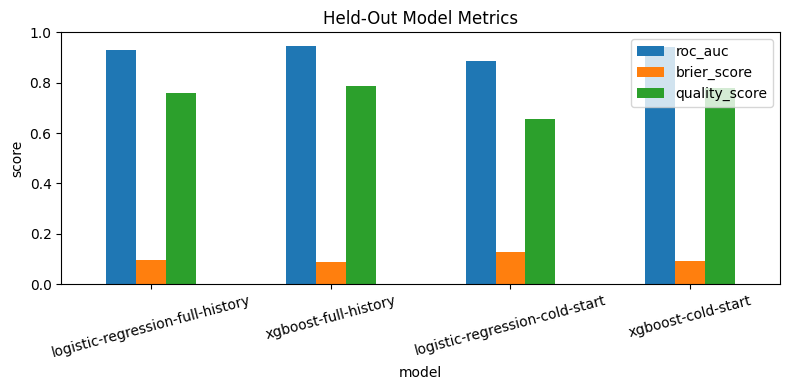

In [8]:
plot_frame = metrics_frame.set_index("model")[["roc_auc", "brier_score", "quality_score"]]
axis = plot_frame.plot(kind="bar", figsize=(8, 4), rot=15, title="Held-Out Model Metrics")
axis.set_ylim(0, 1)
axis.set_ylabel("score")
plt.tight_layout()


## 6. Artifact Export And Staging Notes

This is the artifact boundary used by the application. The notebook writes completed Logistic Regression and XGBoost run JSON files plus a `latest-run.json` pointer; deployment promotion remains a separate staging step.

In [9]:
if export_artifacts:
    latest = write_artifact_bundle(artifact_runs, export_plan.latest_run_path)
else:
    latest = best_run(artifact_runs)

export_frame = pd.DataFrame([
    {
        "model": run["modelName"],
        "artifact_path": run["artifactPath"],
        "dataset_hash": run["datasetHash"],
        "quality_score": run["metrics"]["qualityScore"],
        "exported": bool(export_artifacts),
        "latest_pointer": str(export_plan.latest_run_path) if run["modelName"] == latest["modelName"] else "",
    }
    for run in artifact_runs
])
export_frame


,model,artifact_path,dataset_hash,quality_score,exported,latest_pointer
0,logistic-regression-full-history,c:\Neuer Ordner\oss-risk-radar\tmp\training\ru...,1479ca56fc18e13cad0a9bc85c641ac0f09a054545739e...,0.758658,True,
1,xgboost-full-history,c:\Neuer Ordner\oss-risk-radar\tmp\training\ru...,1479ca56fc18e13cad0a9bc85c641ac0f09a054545739e...,0.788755,True,c:\Neuer Ordner\oss-risk-radar\tmp\training\la...
2,logistic-regression-cold-start,c:\Neuer Ordner\oss-risk-radar\tmp\training\ru...,1479ca56fc18e13cad0a9bc85c641ac0f09a054545739e...,0.656064,True,
3,xgboost-cold-start,c:\Neuer Ordner\oss-risk-radar\tmp\training\ru...,1479ca56fc18e13cad0a9bc85c641ac0f09a054545739e...,0.778652,True,


In [10]:
print("Promote staged artifacts after review:")
print("npm run ml:stage-training")


Promote staged artifacts after review:
npm run ml:stage-training
